# WESAD (Wearable Stress and Affect Detection)
- 목표: 사람의 감정 상태를 탐지하여 인간-컴퓨터 상호작용를 개선하는 것.
- 장기적인 스트레스는 자동화된 지속적인 모니터링 시스템이 필요
- Affective Computing 분야에는
    1. Multimodal의 고품질 데이터
    2. 여러 감정 상태를 포함하는 데이터가 부족하다.
- ref: https://dl.acm.org/doi/epdf/10.1145/3242969.3242985
- ref: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset
---
- Subject: 15명 (S_2/3/4/5/6/7/8/9/10/11/13/14/15/16/17)
- ACC: 3축 가속도 (32Hz)
- BVP: PPG (64Hz)
- EDA: 피부 전도도 (4Hz)
---
감정상태
- Baseline
- Stress
- Amusement
---
2가지 케이스
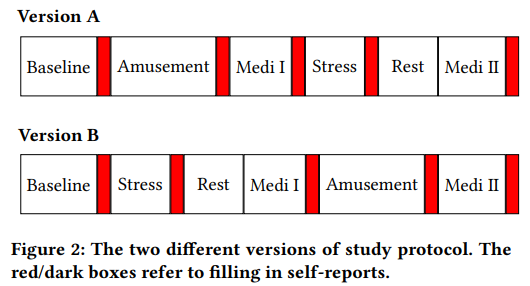
1. Baseline condition
    - 20분
    - 테이블에 앉거나 선 상태로 중립적인 잡지 읽기
→ 중립적인 정서 상태 유도
    

2. Amusement condition
    - 392초
    - 11개의 재미있는 비디오 시청.

3. Stress condition
    - 총 10분
    - 신뢰도가 높은 사회적 스트레스 검사를 사용함.
    - 대중 연설 + 암산 (각 과제당 5분, 총 10분 소요)

4. 중간 중간 Meditation
---
- 방법 A: self-report가 있으니 이걸 GT로 쓰자
- 방법 B: 지금은 실험 프로토콜 상 Stress 시간이니 GT를 Stress로 쓰자.

⇒ **본 논문의 첫 번째 평가에서는 방법 B를 사용함.**

⇒ 설문지는 나중에 정밀연구할 때 쓰라고 보조용.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

acc_path = '/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/ACC.csv'
bvp_path = '/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/BVP.csv'
eda_path = '/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/EDA.csv'

,ACC_X,ACC_Y,ACC_Z
2017-07-25 07:05:08.000000,5,1,63
2017-07-25 07:05:08.031250,5,1,63
2017-07-25 07:05:08.062500,5,1,63
2017-07-25 07:05:08.093750,6,1,63
2017-07-25 07:05:08.125000,5,1,63


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 218328 entries, 2017-07-25 07:05:08 to 2017-07-25 08:58:50.718750
Freq: 31250us
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   ACC_X   218328 non-null  int64
 1   ACC_Y   218328 non-null  int64
 2   ACC_Z   218328 non-null  int64
dtypes: int64(3)
memory usage: 6.7 MB


None

,ACC_X,ACC_Y,ACC_Z
count,218328.000000,218328.000000,218328.000000
mean,41.790480,-7.080457,15.472963
std,18.804473,26.518563,30.140473
min,-108.000000,-128.000000,-106.000000
25%,24.000000,-22.000000,-11.000000
50%,46.000000,-2.000000,11.000000
75%,59.000000,6.000000,49.000000
max,127.000000,94.000000,127.000000


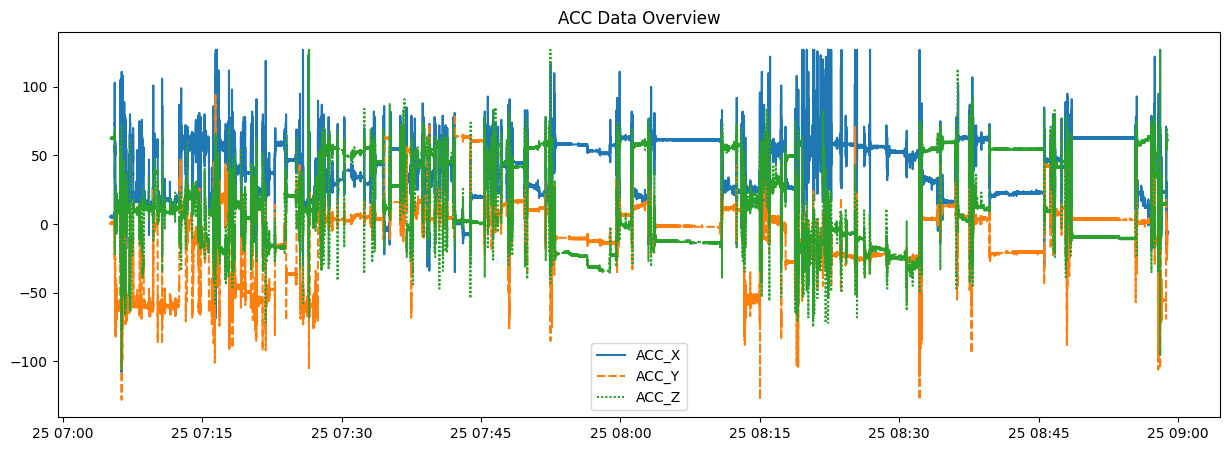

In [2]:
with open(acc_path, 'r') as f:
    start_time = float(f.readline().split(',')[0])
    sample_rate = float(f.readline().split(',')[0])

df_acc = pd.read_csv(acc_path, skiprows=2, names=['ACC_X', 'ACC_Y', 'ACC_Z'])

df_acc.index = pd.date_range(
    start=pd.to_datetime(start_time, unit='s'),
    periods=len(df_acc),
    freq=pd.Timedelta(seconds=1/sample_rate)
)

display(df_acc.head())
display(df_acc.info())
display(df_acc.describe())

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_acc)
plt.title('ACC Data Overview')
plt.show()

,BVP
2017-07-25 07:05:08.000000,-0.0
2017-07-25 07:05:08.015625,-0.0
2017-07-25 07:05:08.031250,-0.0
2017-07-25 07:05:08.046875,-0.0
2017-07-25 07:05:08.062500,-0.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 436645 entries, 2017-07-25 07:05:08 to 2017-07-25 08:58:50.562500
Freq: 15625us
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   BVP     436645 non-null  float64
dtypes: float64(1)
memory usage: 6.7 MB


None

,BVP
count,436645.000000
mean,0.000429
std,46.319997
min,-609.230000
25%,-11.910000
50%,2.250000
75%,12.280000
max,779.690000


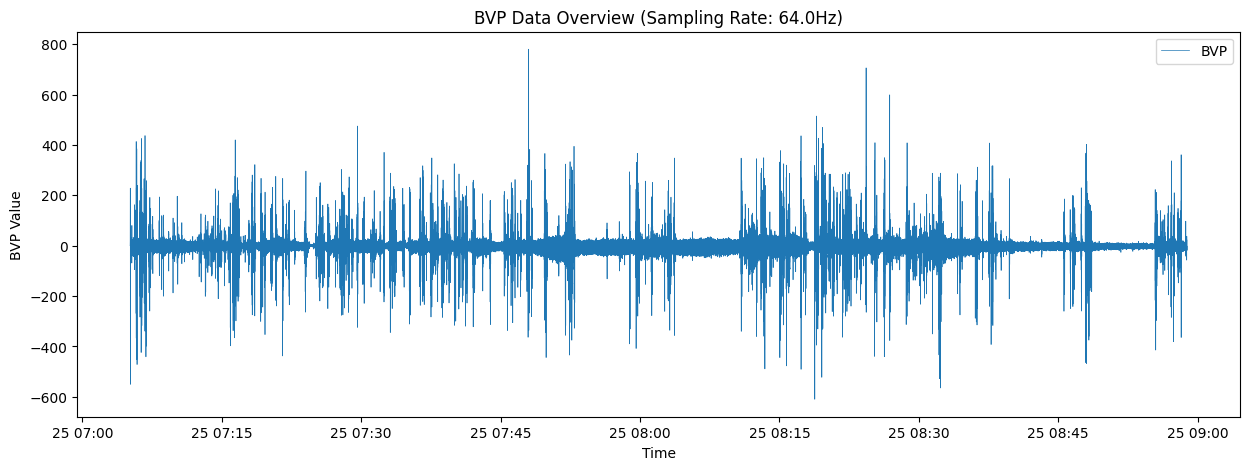

In [7]:
# 1. 파일의 첫 두 줄을 읽어 시작 시간과 주파수 추출
with open(bvp_path, 'r') as f:
    start_time = float(f.readline().split(',')[0])
    sample_rate = float(f.readline().split(',')[0])

# 2. 3번째 줄부터 데이터를 1개의 열(BVP)로 읽어오기
df_bvp = pd.read_csv(bvp_path, skiprows=2, names=['BVP'])

# 3. 측정 시작 시간부터 '1초 / 주파수' 간격으로 시간 인덱스 생성
df_bvp.index = pd.date_range(
    start=pd.to_datetime(start_time, unit='s'),
    periods=len(df_bvp),
    freq=pd.Timedelta(seconds=1/sample_rate)
)

display(df_bvp.head())
display(df_bvp.info())
display(df_bvp.describe())

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_bvp, color='red', linewidth=0.5)
plt.title(f'BVP Data Overview (Sampling Rate: {sample_rate}Hz)')
plt.ylabel('BVP Value')
plt.xlabel('Time')
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_73609/2103475278.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('EDA ($\mu$S)')


,EDA
2017-07-25 07:05:08.000,0.000000
2017-07-25 07:05:08.250,0.226414
2017-07-25 07:05:08.500,0.287814
2017-07-25 07:05:08.750,0.294210
2017-07-25 07:05:09.000,0.295489


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 27288 entries, 2017-07-25 07:05:08 to 2017-07-25 08:58:49.750000
Freq: 250ms
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EDA     27288 non-null  float64
dtypes: float64(1)
memory usage: 426.4 KB


None

,EDA
count,27288.000000
mean,0.856290
std,0.736143
min,0.000000
25%,0.381194
50%,0.444140
75%,1.044241
max,3.507541


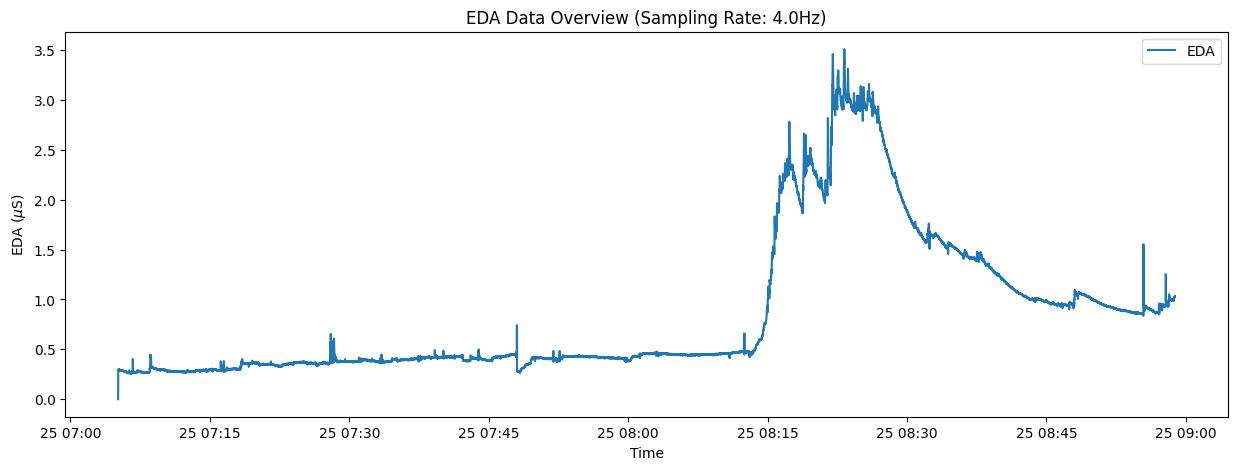

In [8]:
# 1. 파일의 첫 두 줄을 읽어 시작 시간과 주파수 추출
with open(eda_path, 'r') as f:
    start_time = float(f.readline().split(',')[0])
    sample_rate = float(f.readline().split(',')[0])

# 2. 3번째 줄부터 데이터를 1개의 열(EDA)로 읽어오기
df_eda = pd.read_csv(eda_path, skiprows=2, names=['EDA'])

# 3. 측정 시작 시간부터 '1초 / 주파수' 간격으로 시간 인덱스 생성
df_eda.index = pd.date_range(
    start=pd.to_datetime(start_time, unit='s'),
    periods=len(df_eda),
    freq=pd.Timedelta(seconds=1/sample_rate)
)

# 4. 데이터 확인
display(df_eda.head())
display(df_eda.info())
display(df_eda.describe())

# 5. 전체 구간 시각화
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_eda, color='green', linewidth=1.5)
plt.title(f'EDA Data Overview (Sampling Rate: {sample_rate}Hz)')
plt.ylabel('EDA ($\mu$S)')
plt.xlabel('Time')
plt.show()

In [13]:
import pickle
import numpy as np
import pandas as pd

pkl_path = "/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/S10.pkl"

with open(pkl_path, "rb") as f:
    s = pickle.load(f, encoding="latin1")

print("Top keys:", s.keys())
print("subject:", s.get("subject", None))
print("signal keys:", s["signal"].keys())  # 보통 'chest', 'wrist'
print("label dtype/shape:", type(s["label"]), s["label"].shape, s["label"].dtype)
print("unique labels:", np.unique(s["label"]))
print(pd.Series(s["label"]).value_counts().sort_index())

Top keys: dict_keys(['signal', 'label', 'subject'])
subject: S10
signal keys: dict_keys(['chest', 'wrist'])
label dtype/shape: <class 'numpy.ndarray'> (3847200,) int32
unique labels: [0 1 2 3 4 5 6 7]
0    1589000
1     826000
2     507500
3     260400
4     557200
5      35700
6      31500
7      39900
Name: count, dtype: int64


In [14]:
for loc in s["signal"].keys():  # 'chest', 'wrist'
    print(f"\n[{loc}] sensors:", s["signal"][loc].keys())
    for sensor in s["signal"][loc].keys():
        arr = s["signal"][loc][sensor]
        arr = np.asarray(arr)
        print(f"  - {sensor:>5s}: shape={arr.shape}, dtype={arr.dtype}")


[chest] sensors: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
  -   ACC: shape=(3847200, 3), dtype=float64
  -   ECG: shape=(3847200, 1), dtype=float64
  -   EMG: shape=(3847200, 1), dtype=float64
  -   EDA: shape=(3847200, 1), dtype=float64
  -  Temp: shape=(3847200, 1), dtype=float32
  -  Resp: shape=(3847200, 1), dtype=float64

[wrist] sensors: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
  -   ACC: shape=(175872, 3), dtype=float64
  -   BVP: shape=(351744, 1), dtype=float64
  -   EDA: shape=(21984, 1), dtype=float64
  -  TEMP: shape=(21984, 1), dtype=float64


In [12]:
labels = data['label']

print("Label shape:", labels.shape)
print("Unique labels:", np.unique(labels))
print("Label distribution:")
print(pd.Series(labels).value_counts())

Label shape: (3847200,)
Unique labels: [0 1 2 3 4 5 6 7]
Label distribution:
0    1589000
1     826000
4     557200
2     507500
3     260400
7      39900
5      35700
6      31500
Name: count, dtype: int64


In [16]:
import pickle
import numpy as np
import pandas as pd

# =========================
# CONFIG
# =========================
pkl_path = "/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/S10.pkl"

FS_LABEL = 700
FS_BVP   = 64
FS_ACC   = 32
FS_EDA   = 4

WINDOW_SEC = 120
STEP_SEC   = 60

USE_LABELS = {1, 2, 3, 4}     # baseline, stress, amusement, meditation
STRESS_ID  = 2                # stress
MAJ_RATIO_TH = 0.6            # majority가 최소 이 비율 이상일 때만 채택 (원하면 0.5로)

# =========================
# LOAD PKL
# =========================
with open(pkl_path, "rb") as f:
    s = pickle.load(f, encoding="latin1")

w = s["signal"]["wrist"]
labels = np.asarray(s["label"]).astype(np.int64)

bvp = np.asarray(w["BVP"]).reshape(-1)          # (N,)
acc = np.asarray(w["ACC"])                      # (N,3)
eda = np.asarray(w["EDA"]).reshape(-1)          # (N,)

print("Loaded:")
print("  label:", labels.shape, "fs=", FS_LABEL)
print("  bvp  :", bvp.shape,   "fs=", FS_BVP)
print("  acc  :", acc.shape,   "fs=", FS_ACC)
print("  eda  :", eda.shape,   "fs=", FS_EDA)

# =========================
# SAFE DURATION (sec)
# label은 chest 기준으로 더 길 수 있으므로, wrist duration에 맞춰 label도 자름
# =========================
dur_bvp = len(bvp) / FS_BVP
dur_acc = len(acc) / FS_ACC
dur_eda = len(eda) / FS_EDA
dur_wrist = min(dur_bvp, dur_acc, dur_eda)

max_label_len = int(dur_wrist * FS_LABEL)
labels_cut = labels[:max_label_len]

print("\nDuration (sec):")
print("  bvp:", dur_bvp, "acc:", dur_acc, "eda:", dur_eda, "=> wrist(min):", dur_wrist)
print("  label cut len:", len(labels_cut), " (~sec:", len(labels_cut)/FS_LABEL, ")")

# =========================
# WINDOWING
# =========================
Wl = int(WINDOW_SEC * FS_LABEL)
Sl = int(STEP_SEC   * FS_LABEL)

Wb = int(WINDOW_SEC * FS_BVP)
Sb = int(STEP_SEC   * FS_BVP)

Wa = int(WINDOW_SEC * FS_ACC)
Sa = int(STEP_SEC   * FS_ACC)

We = int(WINDOW_SEC * FS_EDA)
Se = int(STEP_SEC   * FS_EDA)

# 결과 저장
X_bvp, X_acc, X_eda = [], [], []
y_bin, y_major = [], []
t_start_sec = []

n_windows = 0
kept = 0

# label 기준으로 윈도우를 돌리되, 각 신호 인덱스로 매핑해서 slice
for start_l in range(0, len(labels_cut) - Wl + 1, Sl):
    end_l = start_l + Wl
    n_windows += 1

    # ---- label majority ----
    win_lab = labels_cut[start_l:end_l]
    # majority label
    maj = int(np.bincount(win_lab).argmax())
    maj_ratio = (win_lab == maj).mean()

    # 1~4만 사용 + majority ratio threshold
    if (maj not in USE_LABELS) or (maj_ratio < MAJ_RATIO_TH):
        continue

    # ---- time(sec) ----
    t0 = start_l / FS_LABEL

    # ---- map to each sensor index ----
    start_b = int(round(t0 * FS_BVP))
    start_a = int(round(t0 * FS_ACC))
    start_e = int(round(t0 * FS_EDA))

    end_b = start_b + Wb
    end_a = start_a + Wa
    end_e = start_e + We

    # boundary check (안전)
    if end_b > len(bvp) or end_a > len(acc) or end_e > len(eda):
        break

    seg_bvp = bvp[start_b:end_b]
    seg_acc = acc[start_a:end_a, :]
    seg_eda = eda[start_e:end_e]

    # binary label (stress=1 else=0)
    y = 1 if maj == STRESS_ID else 0

    X_bvp.append(seg_bvp.astype(np.float32))
    X_acc.append(seg_acc.astype(np.float32))
    X_eda.append(seg_eda.astype(np.float32))

    y_bin.append(y)
    y_major.append(maj)
    t_start_sec.append(t0)
    kept += 1

print(f"\nWindows total={n_windows}, kept={kept} (MAJ_RATIO_TH={MAJ_RATIO_TH})")

# =========================
# STACK TO ARRAYS
# =========================
X_bvp = np.stack(X_bvp, axis=0)   # (N, Wb)
X_acc = np.stack(X_acc, axis=0)   # (N, Wa, 3)
X_eda = np.stack(X_eda, axis=0)   # (N, We)
y_bin = np.asarray(y_bin, dtype=np.int64)
y_major = np.asarray(y_major, dtype=np.int64)
t_start_sec = np.asarray(t_start_sec, dtype=np.float32)

print("\nFinal shapes:")
print("  X_bvp :", X_bvp.shape)
print("  X_acc :", X_acc.shape)
print("  X_eda :", X_eda.shape)
print("  y_bin :", y_bin.shape, "dist:", dict(pd.Series(y_bin).value_counts()))
print("  y_major:", y_major.shape, "dist:", dict(pd.Series(y_major).value_counts().sort_index()))

# =========================
# OPTIONAL: 간단 요약 테이블
# =========================
df_windows = pd.DataFrame({
    "t_start_sec": t_start_sec,
    "label_major": y_major,
    "label_bin": y_bin,
})
display(df_windows.head())
display(df_windows["label_major"].value_counts().sort_index())
display(df_windows["label_bin"].value_counts())

# =========================
# OPTIONAL: 저장 (원하면)
# =========================
# np.savez_compressed(
#     "S10_wrist_windows.npz",
#     X_bvp=X_bvp, X_acc=X_acc, X_eda=X_eda,
#     y_bin=y_bin, y_major=y_major,
#     t_start_sec=t_start_sec,
#     fs_bvp=FS_BVP, fs_acc=FS_ACC, fs_eda=FS_EDA,
#     window_sec=WINDOW_SEC, step_sec=STEP_SEC
# )

Loaded:
  label: (3847200,) fs= 700
  bvp  : (351744,) fs= 64
  acc  : (175872, 3) fs= 32
  eda  : (21984,) fs= 4

Duration (sec):
  bvp: 5496.0 acc: 5496.0 eda: 5496.0 => wrist(min): 5496.0
  label cut len: 3847200  (~sec: 5496.0 )

Windows total=90, kept=50 (MAJ_RATIO_TH=0.6)

Final shapes:
  X_bvp : (50, 7680)
  X_acc : (50, 3840, 3)
  X_eda : (50, 480)
  y_bin : (50,) dist: {0: np.int64(38), 1: np.int64(12)}
  y_major: (50,) dist: {1: np.int64(20), 2: np.int64(12), 3: np.int64(6), 4: np.int64(12)}


,t_start_sec,label_major,label_bin
0,60.0,1,0
1,120.0,1,0
2,180.0,1,0
3,240.0,1,0
4,300.0,1,0


,count
label_major,
1,20
2,12
3,6
4,12


,count
label_bin,
0,38
1,12


1.	baseline
2.	stress
3.	amusement
4.	meditation

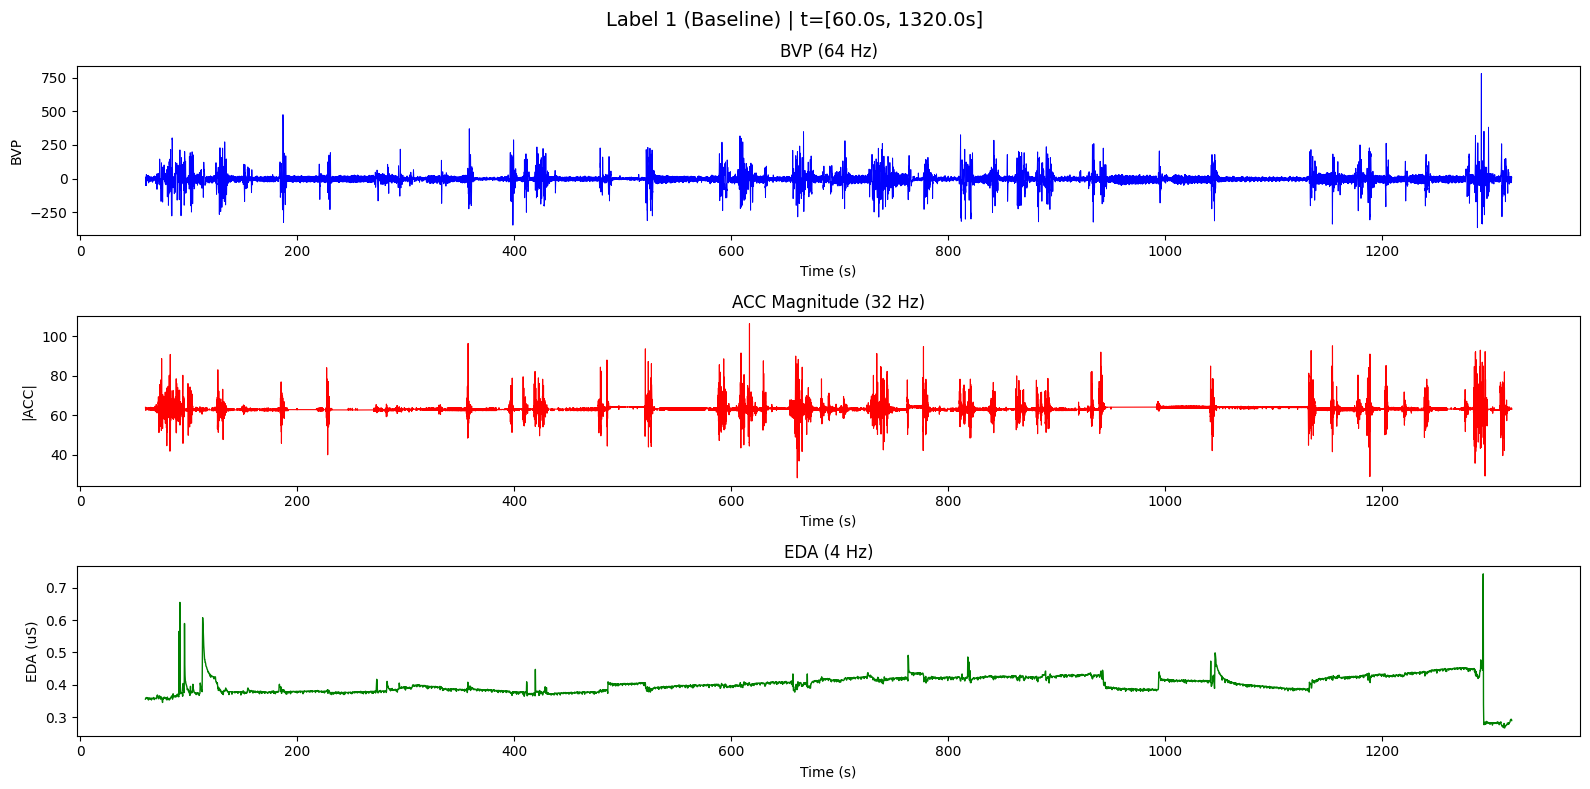

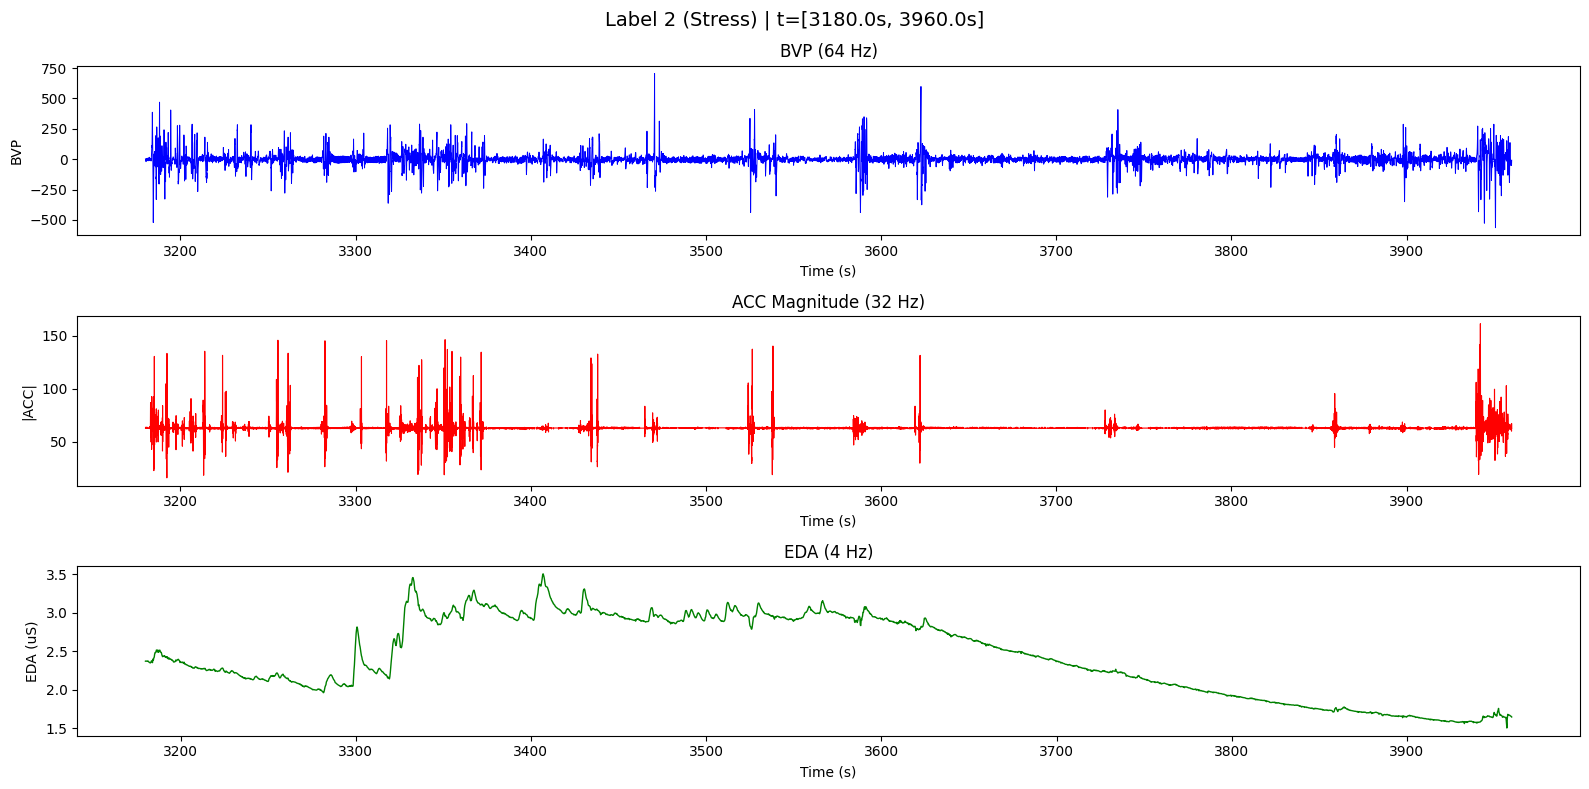

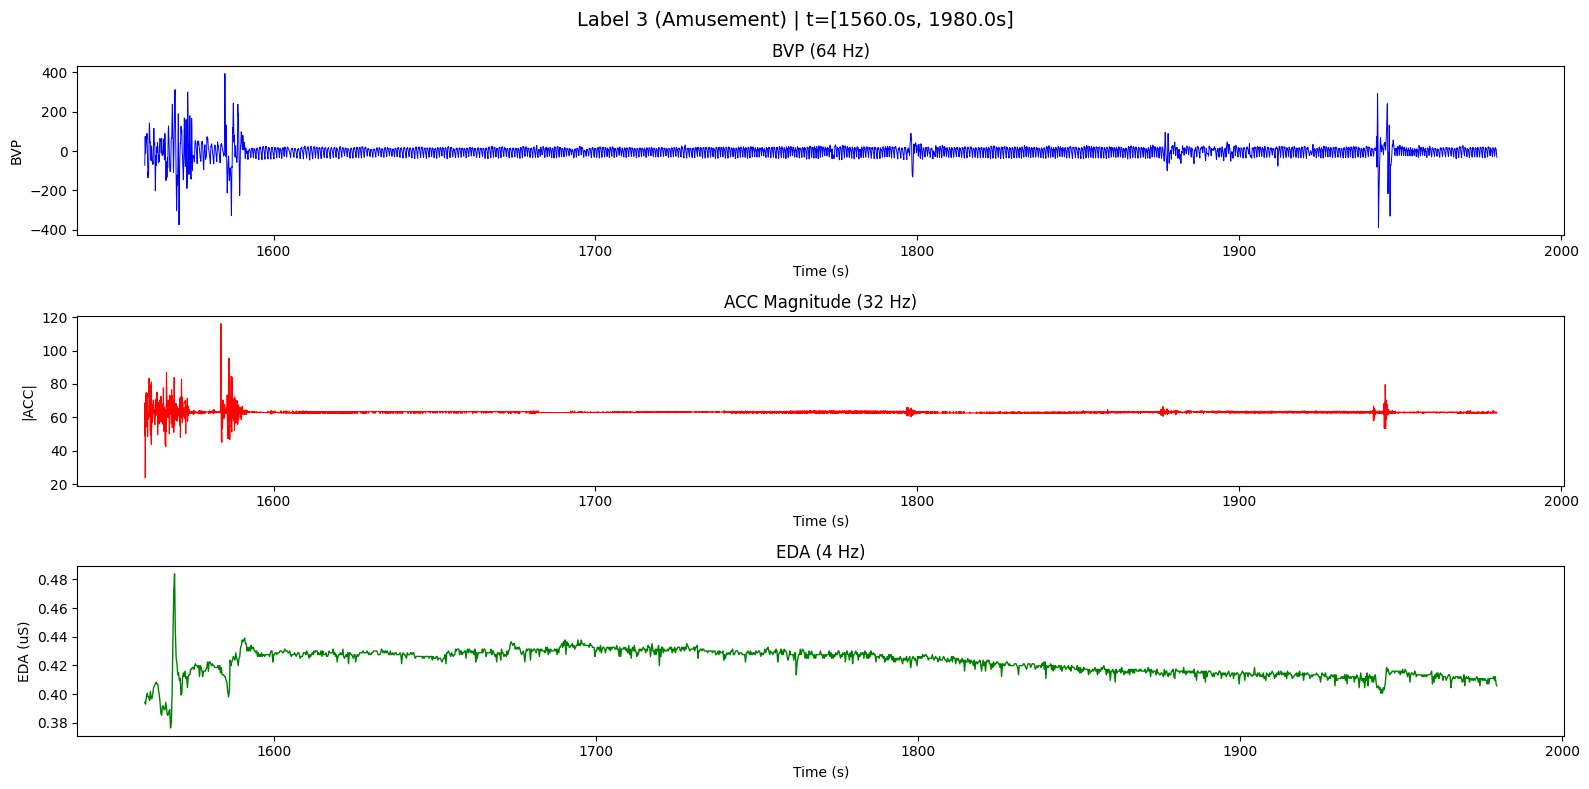

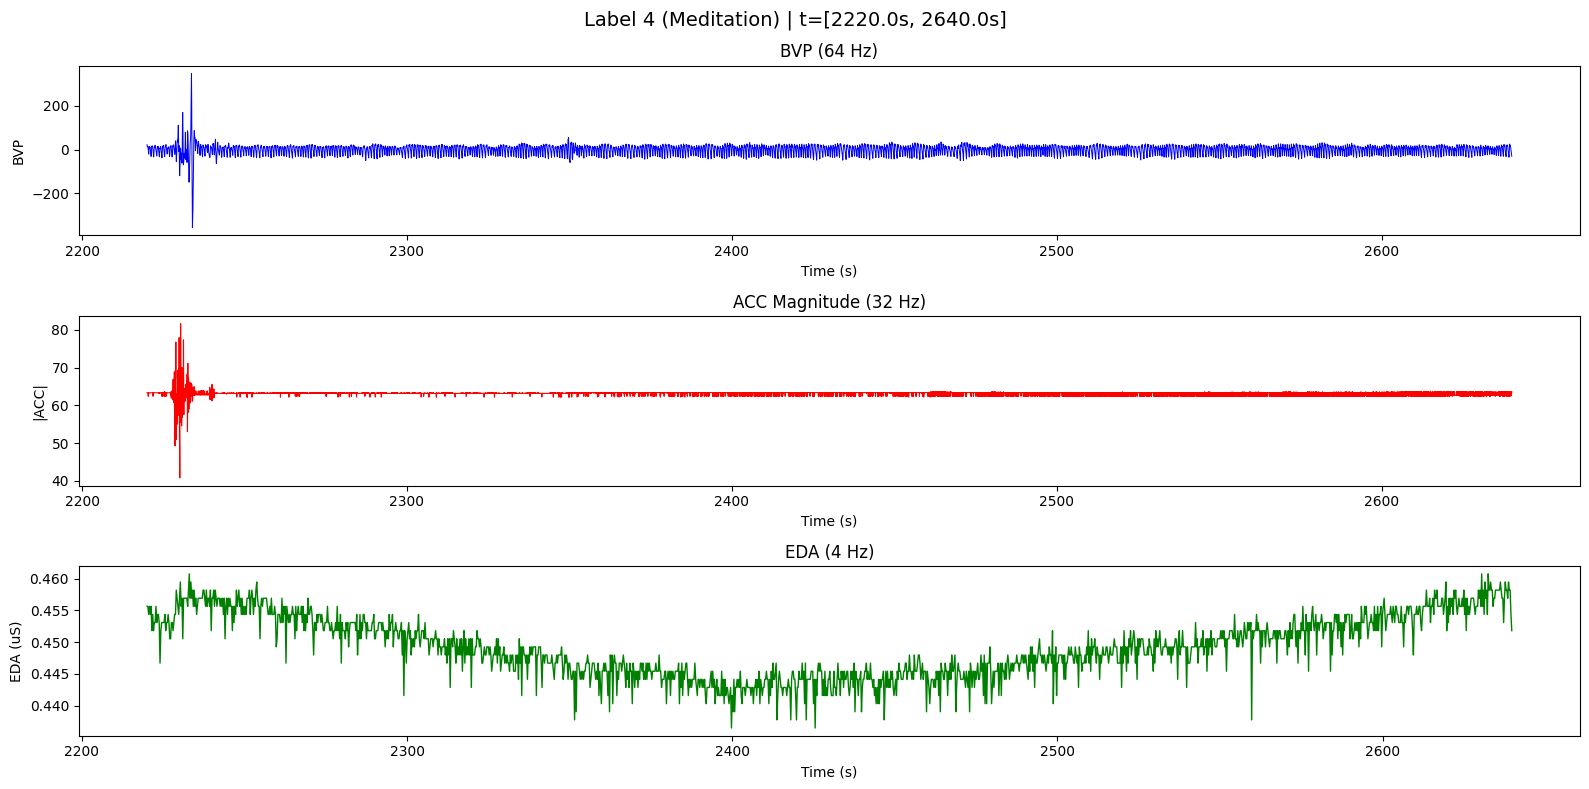

In [18]:
LABEL_NAME = {1:"Baseline", 2:"Stress", 3:"Amusement", 4:"Meditation"}

def pick_longest_run(df_windows, label, step_sec, eps=1e-6):
    """해당 label에서 가장 긴 연속 구간(run)을 (t0, t1)로 반환"""
    df = df_windows[df_windows["label_major"] == label].sort_values("t_start_sec").reset_index(drop=True)
    if len(df) == 0:
        return None

    t = df["t_start_sec"].values
    # 연속성 판단: 다음 윈도우 시작이 정확히 step_sec만큼 증가하면 같은 run
    breaks = np.where(np.diff(t) > (step_sec + eps))[0]  # break index
    # run boundaries
    starts = np.r_[0, breaks + 1]
    ends   = np.r_[breaks, len(t) - 1]

    # 각 run 길이(윈도우 개수) 계산 -> 최대 선택
    lengths = (ends - starts + 1)
    k = np.argmax(lengths)

    run_start = t[starts[k]]
    run_end_last_window_start = t[ends[k]]
    run_end = run_end_last_window_start + WINDOW_SEC  # 마지막 윈도우 끝까지 포함

    return float(run_start), float(run_end)

def slice_by_time(sig, fs, t0, t1):
    """t0~t1(초) 구간을 fs로 index 변환해서 slice"""
    i0 = int(round(t0 * fs))
    i1 = int(round(t1 * fs))
    i0 = max(i0, 0)
    i1 = min(i1, len(sig))
    return sig[i0:i1], np.arange(i0, i1) / fs

def plot_one_label(label, t0, t1):
    # --- slice ---
    seg_bvp, tb = slice_by_time(bvp, FS_BVP, t0, t1)
    seg_acc, ta = slice_by_time(acc, FS_ACC, t0, t1)
    seg_eda, te = slice_by_time(eda, FS_EDA, t0, t1)

    # ACC magnitude
    acc_mag = np.linalg.norm(seg_acc, axis=1)

    # --- plot ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=False)
    fig.suptitle(f"Label {label} ({LABEL_NAME.get(label,'')}) | t=[{t0:.1f}s, {t1:.1f}s]", fontsize=14)

    axes[0].plot(tb, seg_bvp, linewidth=0.7, color='blue')
    axes[0].set_title("BVP (64 Hz)")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("BVP")

    axes[1].plot(ta, acc_mag, linewidth=0.8, color='red')
    axes[1].set_title("ACC Magnitude (32 Hz)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("|ACC|")

    axes[2].plot(te, seg_eda, linewidth=1.0, color='green')
    axes[2].set_title("EDA (4 Hz)")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("EDA (uS)")

    plt.tight_layout()
    plt.show()

# ===== 라벨 1~4 각각 plot (총 4장) =====
for lab in [1, 2, 3, 4]:
    run = pick_longest_run(df_windows, lab, STEP_SEC)
    if run is None:
        print(f"[Skip] label {lab}: no windows")
        continue
    t0, t1 = run
    plot_one_label(lab, t0, t1)